# Phase C — Modeling, Comparison, Ablation & Scope

This is the **Modeling** + **Evaluation** phase of CRISP-DM. It consumes the leakage-safe datasets
built in **Phase B** (`Phase_B_Pipeline.ipynb`, scope `scope2_2000single`) and runs the full study in
one place:

- **Part 1 — Build & tune the six course classifiers** (kNN, Naive Bayes, Decision Tree, Random
  Forest, Logistic Regression, MLP/ANN), each run twice: no-resample vs train-only 50/50 downsample.
- **C2 — Model comparison** (No-free-lunch): master table + combined ROC → pick a winner.
- **C3 — Feature ablation**: does the engineered `Publisher_Tier` actually matter?
- **C4 — Scope comparison** + a **fair same-test-rows** check (does dropping pre-2000 / segmenting help?).
- **C5 — Downsampling** effect, and a **top-3 robustness** repeat of C3/C4.

**Hard rules throughout:** encoders/scalers live inside scikit-learn `Pipeline`s (fit on the train
fold only), per-model encoding (Ordinal for CategoricalNB, OneHot otherwise), downsampling on
**train only**, RF skips CV (skipped per supervisor recommendation), `random_state=42` everywhere, the test set is never touched.

## 0. Setup — project root, imports, shared utilities

In [1]:
# Run this cell first. It fixes the common Jupyter problem where the kernel
# is started from a folder that is not the project root.
from pathlib import Path
import os
import sys
import warnings


def looks_like_project_root(path: Path) -> bool:
    return (
        (path / "src" / "ml_utils.py").is_file()
        and (path / "data" / "processed" / "scope2_2000single").is_dir()
    )


def find_project_root() -> Path:
    """Find ML_Project-main even if Jupyter was opened from another folder."""
    cwd = Path.cwd().resolve()
    candidates = []

    # Current folder and parents.
    candidates.extend([cwd, *cwd.parents])

    # Common places where students unzip projects.
    common_bases = [
        cwd,
        cwd.parent,
        Path.home(),
        Path.home() / "Downloads",
        Path.home() / "Desktop",
        Path("/mnt/data"),
    ]
    for base in common_bases:
        candidates.extend([
            base / "ML_Project-main",
            base / "ML_Project-main-main",
            base / "ML_Project",
        ])

    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if looks_like_project_root(candidate):
            return candidate

    raise FileNotFoundError(
        "Could not find the project root. Start Jupyter inside the ML_Project folder "
        "or update PROJECT_ROOT manually."
    )


PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("ml_utils exists:", (PROJECT_ROOT / "src" / "ml_utils.py").is_file())

Project root: /Users/student/Desktop/ML_Project_Group
ml_utils exists: True


In [2]:
# Imports (after the project root is fixed)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning

from src.ml_utils import (load_scope, make_encoder, downsample_5050,
                          evaluate, plot_roc_curves, null_accuracy,
                          RANDOM_STATE, CAT_COLS)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

SCOPE_PATH  = "data/processed/scope2_2000single"
# One results file per model family (kept for the C2 master table). Removed up-front so re-running
# the notebook does not append duplicate rows.
RESULTS_P1 = "results/person1_results.csv"   # kNN + Naive Bayes
RESULTS_P2 = "results/person2_results.csv"   # Decision Tree + Random Forest
RESULTS_P3 = "results/person3_results.csv"   # Logistic Regression + MLP
for f in (RESULTS_P1, RESULTS_P2, RESULTS_P3):
    if os.path.exists(f):
        os.remove(f)

print("CAT_COLS:", CAT_COLS, "| RANDOM_STATE:", RANDOM_STATE)

CAT_COLS: ['Genre_Clean', 'Platform_Family', 'Publisher_Tier'] | RANDOM_STATE: 42


## 0.1 Load the processed data, class balance & null baseline

In [3]:
X_train, X_test, y_train, y_test = load_scope(SCOPE_PATH)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Train class balance:")
print(y_train.value_counts(normalize=True).rename("share"))
print("\nTest class balance:")
print(y_test.value_counts(normalize=True).rename("share"))
print("\nNull-accuracy baseline on test:", round(null_accuracy(y_test), 4))
X_train.head()

X_train: (15472, 3)
X_test : (3868, 3)
Train class balance:
Hit
0   0.7405
1   0.2595
Name: share, dtype: float64

Test class balance:
Hit
0   0.7404
1   0.2596
Name: share, dtype: float64

Null-accuracy baseline on test: 0.7404


,Genre_Clean,Platform_Family,Publisher_Tier
0,Fighting,Other,Tier3
1,Shooter,Playstation,Tier3
2,Action,Playstation,Tier3
3,Action-Adventure,Nintendo,Tier1
4,Sports,Nintendo,Tier2


## 0.2 Leakage guard — features must be exactly the 3 allowed categoricals
A hard-rule assertion: only `Genre_Clean`, `Platform_Family`, `Publisher_Tier` may reach a model; the target/leakage columns must be absent.

In [4]:
forbidden_cols = {"total_sales", "critic_score", "Is_Iconic", "title", "year", "Hit"}

assert list(X_train.columns) == CAT_COLS, f"Unexpected train columns: {list(X_train.columns)}"
assert list(X_test.columns) == CAT_COLS, f"Unexpected test columns: {list(X_test.columns)}"
assert forbidden_cols.isdisjoint(X_train.columns), f"Forbidden columns in X_train: {forbidden_cols & set(X_train.columns)}"
assert forbidden_cols.isdisjoint(X_test.columns), f"Forbidden columns in X_test: {forbidden_cols & set(X_test.columns)}"
assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)

print("Leakage checks passed. Features used:", list(X_train.columns))

Leakage checks passed. Features used: ['Genre_Clean', 'Platform_Family', 'Publisher_Tier']


## 0.3 The 50/50 balanced training set (TRAIN ONLY)
Computed once and reused by every "(50/50)" run below. Prof. Goldstein's 'balance the classes during training' (Lec 5); the test set is left at its natural ~74/26 split.

In [5]:
X_train_bal, y_train_bal = downsample_5050(X_train, y_train)
print("Original train counts:")
print(y_train.value_counts())
print("\nBalanced (50/50) train counts:")
print(y_train_bal.value_counts())

Original train counts:
Hit
0    11457
1     4015
Name: count, dtype: int64

Balanced (50/50) train counts:
1    4015
0    4015
Name: count, dtype: int64


# Part 1 — Build & tune the six classifiers

Each model is a scikit-learn `Pipeline` (encoder + optional scaler + classifier) and is evaluated
**twice** — on the full imbalanced train (`no-resample`) and on the 50/50 balanced train. kNN and the
Decision Tree are tuned with `GridSearchCV(cv=10, scoring="roc_auc")` on the **train fold only**;
Random Forest uses a fixed config and skips CV (supervisor recommendation — RF tuning barely helps). Every run appends one row (precision/recall/
F1/ROC-AUC + null baseline) to its model-family results file, which the C2 master table then merges.

## 3. kNN — OHE + scaling + GridSearchCV(cv=10)

kNN is distance-based, so it needs scaling after one-hot encoding.  
The encoder and scaler stay **inside** the pipeline, so during `GridSearchCV` they are fit only on each training fold, not on validation folds or test data.

We tune `n_neighbors` from 5 to 51 (the course preference is k >= 10). The course preference is `k ≥ 10`, so if the best value comes out below 10, mention that in the interpretation and compare it against the best `k ≥ 10` value.

In [6]:
def make_knn_pipeline():
    return Pipeline([
        ("enc", make_encoder("onehot")),
        # with_mean=False is required because OneHotEncoder returns a sparse matrix.
        ("scale", StandardScaler(with_mean=False)),
        ("clf", KNeighborsClassifier(n_jobs=-1)),
    ])


KNN_PARAM_GRID = {
    # Odd values avoid exact tie-vote situations. This covers the requested 5-51 range.
    "clf__n_neighbors": list(range(5, 52, 2)),
}


def tune_knn(X, y, label):
    """Tune k on TRAIN data only. Never pass X_test/y_test here."""
    gs = GridSearchCV(
        estimator=make_knn_pipeline(),
        param_grid=KNN_PARAM_GRID,
        cv=10,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1,
    )
    gs.fit(X, y)

    cv_results = (
        pd.DataFrame(gs.cv_results_)
        .sort_values("rank_test_score")
        [["param_clf__n_neighbors", "mean_test_score", "std_test_score", "rank_test_score"]]
    )

    print(f"Best kNN params ({label}):", gs.best_params_)
    print(f"Best CV ROC-AUC ({label}):", round(gs.best_score_, 4))

    best_k = gs.best_params_["clf__n_neighbors"]
    if best_k < 10:
        print("Note: Prof. Goldstein recommends k >= 10. Check the CV table before reporting.")

    display(cv_results.head(10))
    return gs.best_estimator_, cv_results

Fitting 10 folds for each of 24 candidates, totalling 240 fits


Best kNN params (no-resample): {'clf__n_neighbors': 41}
Best CV ROC-AUC (no-resample): 0.7246


,param_clf__n_neighbors,mean_test_score,std_test_score,rank_test_score
18,41,0.7246,0.0159,1
19,43,0.7245,0.0163,2
20,45,0.7244,0.0156,3
21,47,0.7244,0.0156,4
23,51,0.7242,0.0138,5
22,49,0.7241,0.0149,6
17,39,0.7234,0.0158,7
16,37,0.7226,0.0157,8
15,35,0.7223,0.0165,9
14,33,0.7218,0.0159,10



=== kNN (no-resample) ===
              precision    recall  f1-score   support

           0      0.773     0.917     0.839      2864
           1      0.494     0.230     0.314      1004

    accuracy                          0.739      3868
   macro avg      0.633     0.574     0.576      3868
weighted avg      0.700     0.739     0.703      3868

ROC-AUC: 0.722 | F1: 0.3139 | null-accuracy baseline: 0.7404


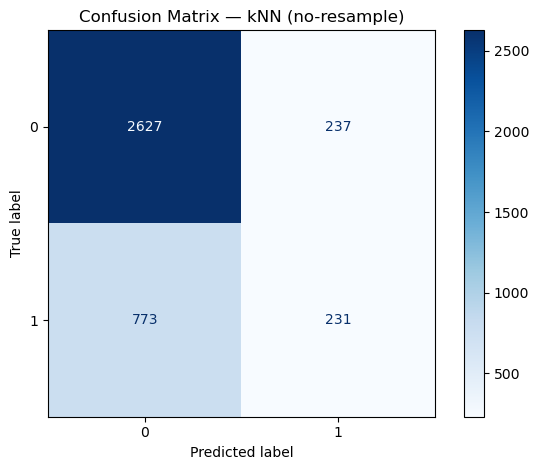

Fitting 10 folds for each of 24 candidates, totalling 240 fits


Best kNN params (50/50): {'clf__n_neighbors': 49}
Best CV ROC-AUC (50/50): 0.725


,param_clf__n_neighbors,mean_test_score,std_test_score,rank_test_score
22,49,0.7250,0.0202,1
23,51,0.7249,0.0191,2
21,47,0.7243,0.0194,3
20,45,0.7232,0.0193,4
19,43,0.7226,0.0194,5
14,33,0.7222,0.0191,6
17,39,0.7219,0.0196,7
18,41,0.7217,0.0195,8
15,35,0.7214,0.0193,9
12,29,0.7213,0.0189,10



=== kNN (50/50) ===
              precision    recall  f1-score   support

           0      0.859     0.609     0.713      2864
           1      0.391     0.715     0.505      1004

    accuracy                          0.637      3868
   macro avg      0.625     0.662     0.609      3868
weighted avg      0.738     0.637     0.659      3868

ROC-AUC: 0.7105 | F1: 0.5053 | null-accuracy baseline: 0.7404


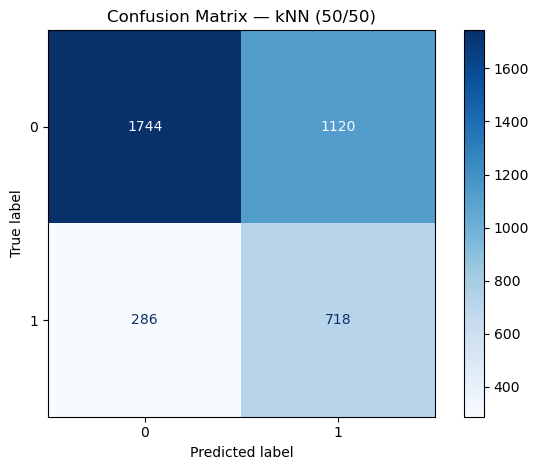

{'model': 'kNN (50/50)',
 'accuracy': 0.6365,
 'precision': 0.3906,
 'recall': 0.7151,
 'f1': 0.5053,
 'roc_auc': 0.7105,
 'null_acc': np.float64(0.7404),
 'n_train': 8030,
 'n_test': 3868}

In [7]:
# kNN tuned on each training set, then evaluated on the untouched test set.
best_knn, _ = tune_knn(X_train, y_train, "no-resample")
evaluate("kNN (no-resample)", best_knn, X_train, y_train, X_test, y_test,
         results_csv=RESULTS_P1, plot=True)

best_knn_bal, _ = tune_knn(X_train_bal, y_train_bal, "50/50")
evaluate("kNN (50/50)", best_knn_bal, X_train_bal, y_train_bal, X_test, y_test,
         results_csv=RESULTS_P1, plot=True)

## 4. Naive Bayes — OrdinalEncoder + CategoricalNB

`CategoricalNB` is the correct Naive Bayes variant here because all three inputs are categorical.  
It needs **integer-coded categories**, so this uses `make_encoder("ordinal")`, not one-hot.

We run two versions:

1. `fit_prior=True` — default; learns the original class prior.
2. `fit_prior=False` — ignores the learned class prior; this is the imbalance trick mentioned in the course notes.


=== CategoricalNB fit_prior=True (no-resample) ===
              precision    recall  f1-score   support

           0      0.778     0.917     0.842      2864
           1      0.516     0.252     0.339      1004

    accuracy                          0.745      3868
   macro avg      0.647     0.585     0.590      3868
weighted avg      0.710     0.745     0.711      3868

ROC-AUC: 0.7205 | F1: 0.3387 | null-accuracy baseline: 0.7404


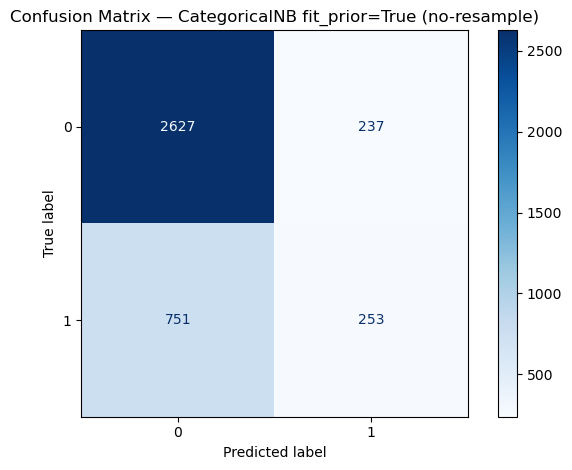


=== CategoricalNB fit_prior=False (no-resample) ===
              precision    recall  f1-score   support

           0      0.861     0.622     0.722      2864
           1      0.399     0.714     0.512      1004

    accuracy                          0.646      3868
   macro avg      0.630     0.668     0.617      3868
weighted avg      0.741     0.646     0.668      3868

ROC-AUC: 0.7205 | F1: 0.5116 | null-accuracy baseline: 0.7404


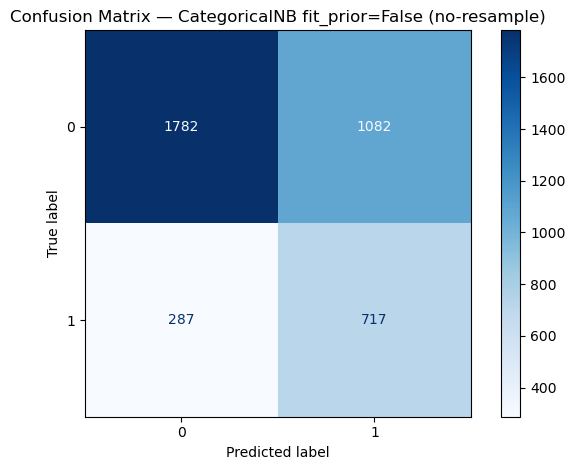


=== CategoricalNB fit_prior=True (50/50) ===
              precision    recall  f1-score   support

           0      0.862     0.632     0.729      2864
           1      0.404     0.711     0.515      1004

    accuracy                          0.653      3868
   macro avg      0.633     0.672     0.622      3868
weighted avg      0.743     0.653     0.674      3868

ROC-AUC: 0.7206 | F1: 0.5152 | null-accuracy baseline: 0.7404


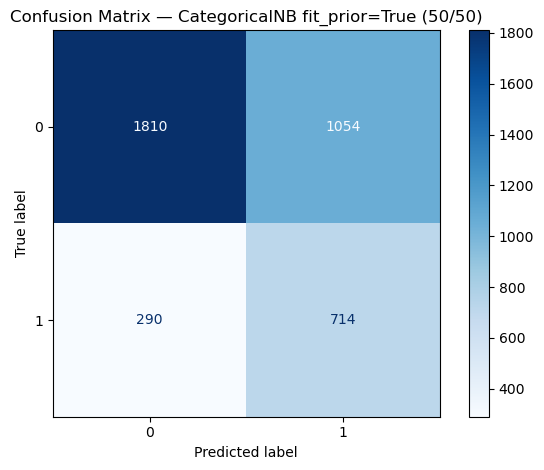


=== CategoricalNB fit_prior=False (50/50) ===
              precision    recall  f1-score   support

           0      0.862     0.632     0.729      2864
           1      0.404     0.711     0.515      1004

    accuracy                          0.653      3868
   macro avg      0.633     0.672     0.622      3868
weighted avg      0.743     0.653     0.674      3868

ROC-AUC: 0.7206 | F1: 0.5152 | null-accuracy baseline: 0.7404


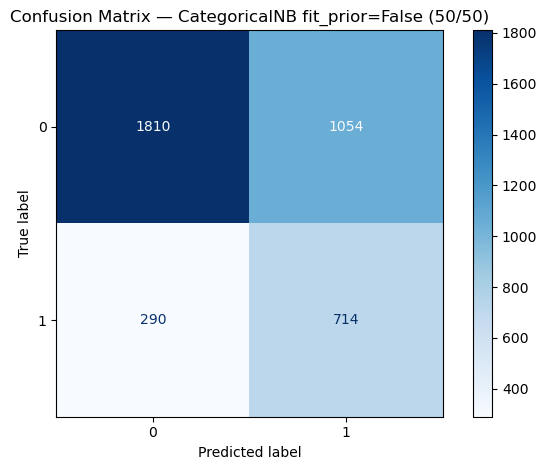

In [8]:
# Naive Bayes: CategoricalNB needs integer codes -> OrdinalEncoder (per-model encoding).
# fit_prior=True learns the class prior; fit_prior=False drops it (an imbalance trick).
def make_nb_pipeline(fit_prior=True):
    return Pipeline([
        ("enc", make_encoder("ordinal")),
        ("clf", CategoricalNB(alpha=1.0, fit_prior=fit_prior)),
    ])

for fp in (True, False):
    evaluate(f"CategoricalNB fit_prior={fp} (no-resample)", make_nb_pipeline(fp),
             X_train, y_train, X_test, y_test, results_csv=RESULTS_P1, plot=True)
for fp in (True, False):
    evaluate(f"CategoricalNB fit_prior={fp} (50/50)", make_nb_pipeline(fp),
             X_train_bal, y_train_bal, X_test, y_test, results_csv=RESULTS_P1, plot=True)

## 1.3 Decision Tree — OneHot + GridSearchCV(cv=10)
Trees need no scaling. We tune `max_depth` / `min_samples_leaf` on the train fold only; the tuning metric is `roc_auc` (threshold-independent on imbalanced data).

In [9]:
# --- Decision Tree: OHE encoder + tree (trees need NO scaling). Tune via GridSearchCV(cv=10). ---
# Tuning metric = roc_auc (one of our two primary metrics; threshold-independent on imbalanced data).
def make_dt_pipeline():
    return Pipeline([
        ("enc", make_encoder("onehot")),
        ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ])

DT_PARAM_GRID = {
    "clf__max_depth": [3, 5, 7, 10, None],
    "clf__min_samples_leaf": [1, 5, 10, 20, 50],
}

def tune_dt(X, y):
    gs = GridSearchCV(make_dt_pipeline(), DT_PARAM_GRID, cv=10,
                      scoring="roc_auc", n_jobs=-1)
    gs.fit(X, y)
    print("Best DT params:", gs.best_params_, "| CV roc_auc:", round(gs.best_score_, 4))
    return gs.best_estimator_


Best DT params: {'clf__max_depth': None, 'clf__min_samples_leaf': 20} | CV roc_auc: 0.7351

=== Decision Tree (no-resample) ===
              precision    recall  f1-score   support

           0      0.771     0.933     0.845      2864
           1      0.525     0.211     0.301      1004

    accuracy                          0.746      3868
   macro avg      0.648     0.572     0.573      3868
weighted avg      0.707     0.746     0.703      3868

ROC-AUC: 0.7317 | F1: 0.3011 | null-accuracy baseline: 0.7404


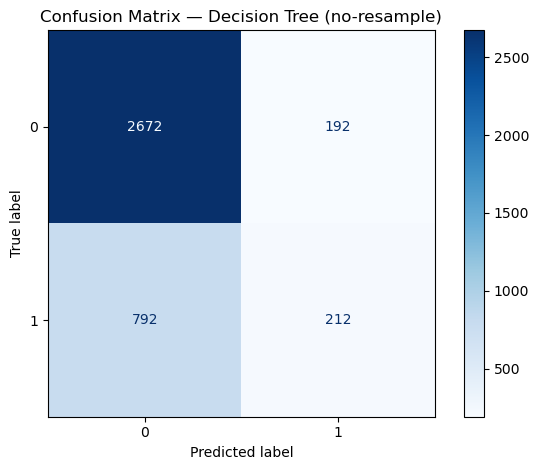

Best DT params: {'clf__max_depth': None, 'clf__min_samples_leaf': 10} | CV roc_auc: 0.7339

=== Decision Tree (50/50) ===
              precision    recall  f1-score   support

           0      0.867     0.627     0.728      2864
           1      0.405     0.726     0.520      1004

    accuracy                          0.653      3868
   macro avg      0.636     0.676     0.624      3868
weighted avg      0.747     0.653     0.674      3868

ROC-AUC: 0.7282 | F1: 0.5203 | null-accuracy baseline: 0.7404


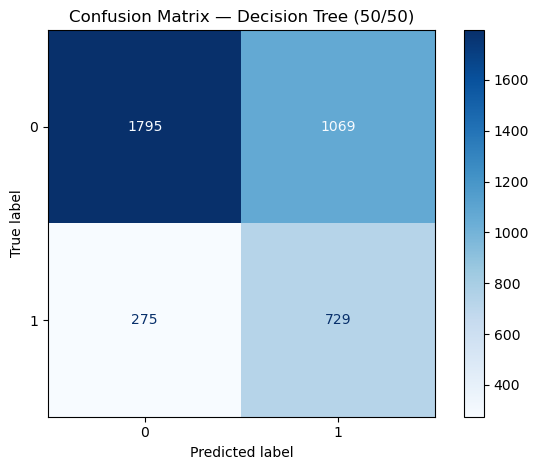

{'model': 'Decision Tree (50/50)',
 'accuracy': 0.6525,
 'precision': 0.4055,
 'recall': 0.7261,
 'f1': 0.5203,
 'roc_auc': 0.7282,
 'null_acc': np.float64(0.7404),
 'n_train': 8030,
 'n_test': 3868}

In [10]:
best_dt = tune_dt(X_train, y_train)
evaluate("Decision Tree (no-resample)", best_dt, X_train, y_train, X_test, y_test,
         results_csv=RESULTS_P2, plot=True)

best_dt_bal = tune_dt(X_train_bal, y_train_bal)
evaluate("Decision Tree (50/50)", best_dt_bal, X_train_bal, y_train_bal, X_test, y_test,
         results_csv=RESULTS_P2, plot=True)

### 1.3a Tree visualisation (explainability — the professor values this)

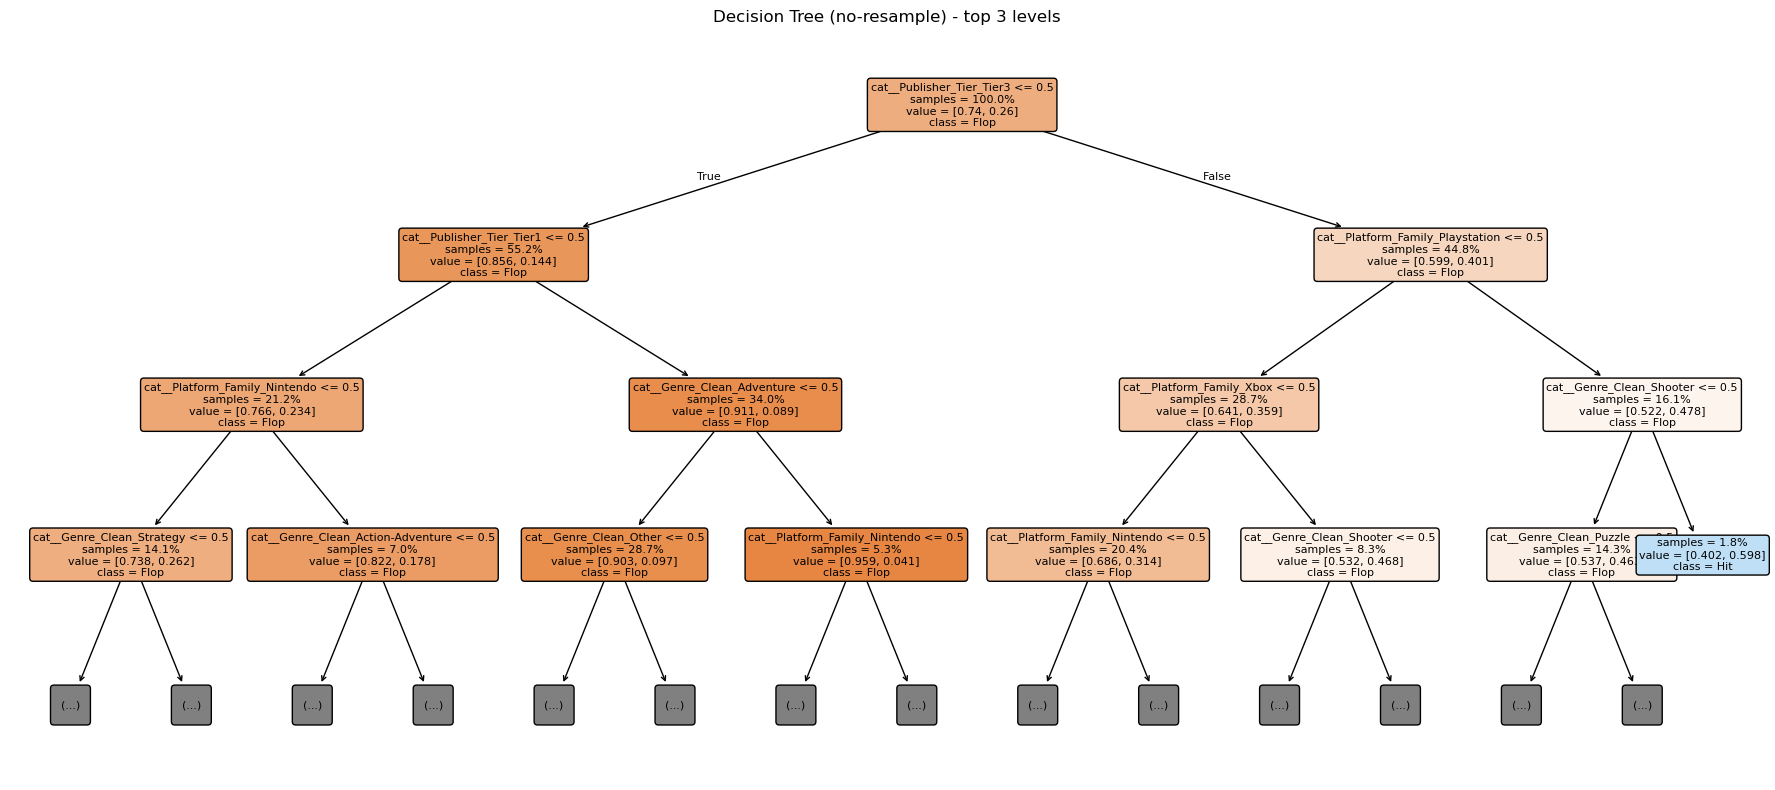

In [11]:
# Explainability: plot the no-resample best tree (depth-limited for readability). Prof. likes this.
enc = best_dt.named_steps["enc"]
feat_names = list(enc.get_feature_names_out())
plt.figure(figsize=(18, 8))
plot_tree(best_dt.named_steps["clf"], feature_names=feat_names,
          class_names=["Flop", "Hit"], filled=True, rounded=True,
          max_depth=3, fontsize=8, impurity=False, proportion=True)
plt.title("Decision Tree (no-resample) - top 3 levels")
plt.tight_layout(); plt.show()


## 1.4 Random Forest — fixed config, NO CV (skipped per supervisor)
The supervisor noted RF tuning barely helps, so we use a fixed, reasonable config and skip cross-validation.


=== Random Forest (no-resample) ===
              precision    recall  f1-score   support

           0      0.754     0.983     0.853      2864
           1      0.634     0.085     0.149      1004

    accuracy                          0.750      3868
   macro avg      0.694     0.534     0.501      3868
weighted avg      0.723     0.750     0.671      3868

ROC-AUC: 0.7284 | F1: 0.1494 | null-accuracy baseline: 0.7404


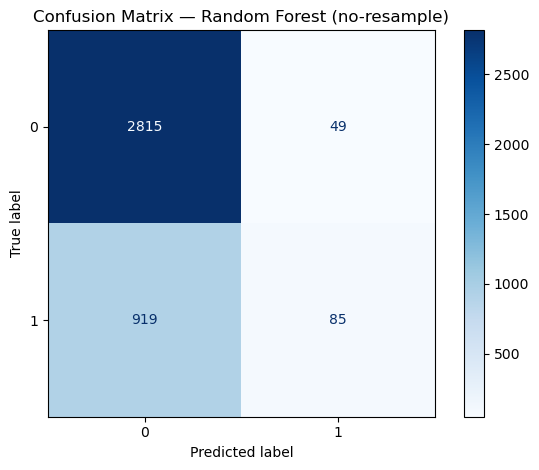


=== Random Forest (50/50) ===
              precision    recall  f1-score   support

           0      0.876     0.606     0.717      2864
           1      0.402     0.755     0.525      1004

    accuracy                          0.645      3868
   macro avg      0.639     0.681     0.621      3868
weighted avg      0.753     0.645     0.667      3868

ROC-AUC: 0.7278 | F1: 0.5247 | null-accuracy baseline: 0.7404


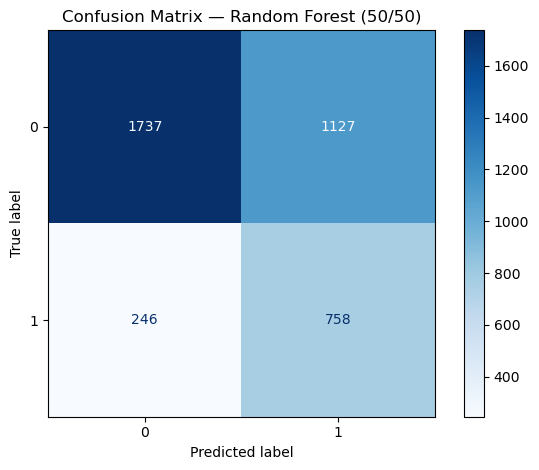

{'model': 'Random Forest (50/50)',
 'accuracy': 0.645,
 'precision': 0.4021,
 'recall': 0.755,
 'f1': 0.5247,
 'roc_auc': 0.7278,
 'null_acc': np.float64(0.7404),
 'n_train': 8030,
 'n_test': 3868}

In [12]:
# Random Forest: fixed config (skip CV — supervisor recommendation). OneHot encoder; no scaling needed for trees.
def make_rf_pipeline():
    return Pipeline([
        ("enc", make_encoder("onehot")),
        ("clf", RandomForestClassifier(n_estimators=300, max_features="sqrt", max_depth=7,
                                       random_state=RANDOM_STATE, n_jobs=-1)),
    ])

rf = make_rf_pipeline()
evaluate("Random Forest (no-resample)", rf, X_train, y_train, X_test, y_test,
         results_csv=RESULTS_P2, plot=True)

rf_bal = make_rf_pipeline()
evaluate("Random Forest (50/50)", rf_bal, X_train_bal, y_train_bal, X_test, y_test,
         results_csv=RESULTS_P2, plot=True)

### 1.4a Random Forest feature importances — which pre-release signals drive Hit/Flop?

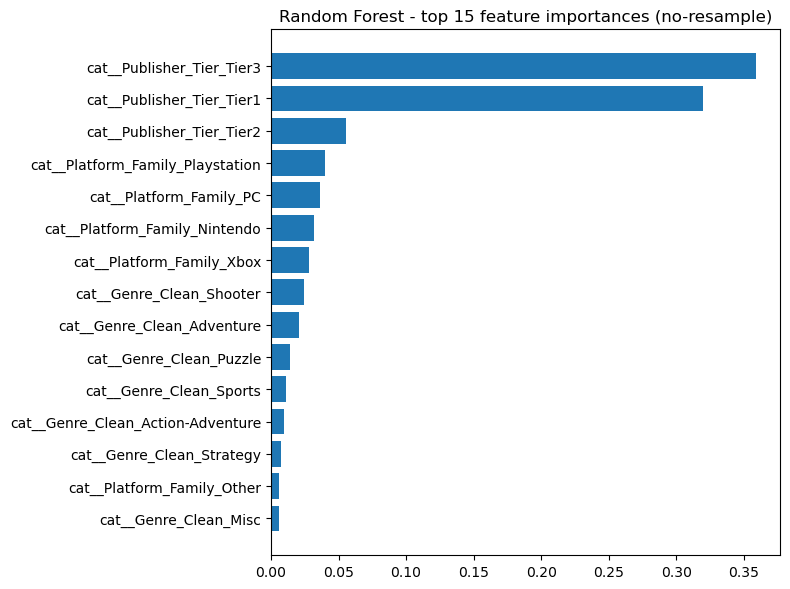

In [13]:
# RF feature importances (no-resample) - which pre-release signals drive Hit/Flop?
import numpy as np
rf_feat = list(rf.named_steps["enc"].get_feature_names_out())
imp = rf.named_steps["clf"].feature_importances_
order = np.argsort(imp)[::-1][:15]
plt.figure(figsize=(8, 6))
plt.barh([rf_feat[i] for i in order][::-1], imp[order][::-1])
plt.title("Random Forest - top 15 feature importances (no-resample)")
plt.tight_layout(); plt.show()


## 1.5 Logistic Regression & 1.6 Simple ANN / MLP
The taught linear "neuron" model (Lec 9) and a single-hidden-layer MLP (kept deliberately simple — deep nets are only an "outlook" in the course). Both need scaling after one-hot encoding.

In [14]:
def make_logreg_pipeline():
    return Pipeline([
        ("enc", make_encoder("onehot")),
        ("scale", StandardScaler(with_mean=False)),
        ("clf", LogisticRegression(
            C=1.0,
            penalty="l2",
            solver="lbfgs",
            random_state=RANDOM_STATE,
            max_iter=1000,
        )),
    ])


def make_mlp_pipeline():
    return Pipeline([
        ("enc", make_encoder("onehot")),
        ("scale", StandardScaler(with_mean=False)),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(16,),
            max_iter=500,
            random_state=RANDOM_STATE,
        )),
    ])

logreg_pipe = make_logreg_pipeline()
mlp_pipe = make_mlp_pipeline()

logreg_pipe, mlp_pipe


(Pipeline(steps=[('enc',
                  ColumnTransformer(transformers=[('cat',
                                                   OneHotEncoder(handle_unknown='ignore'),
                                                   ['Genre_Clean',
                                                    'Platform_Family',
                                                    'Publisher_Tier'])])),
                 ('scale', StandardScaler(with_mean=False)),
                 ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
 Pipeline(steps=[('enc',
                  ColumnTransformer(transformers=[('cat',
                                                   OneHotEncoder(handle_unknown='ignore'),
                                                   ['Genre_Clean',
                                                    'Platform_Family',
                                                    'Publisher_Tier'])])),
                 ('scale', StandardScaler(with_mean=False)),
                 ('clf',


=== Logistic Regression (no-resample) ===
              precision    recall  f1-score   support

           0      0.758     0.972     0.852      2864
           1      0.585     0.113     0.189      1004

    accuracy                          0.749      3868
   macro avg      0.672     0.542     0.520      3868
weighted avg      0.713     0.749     0.679      3868

ROC-AUC: 0.7215 | F1: 0.1888 | null-accuracy baseline: 0.7404


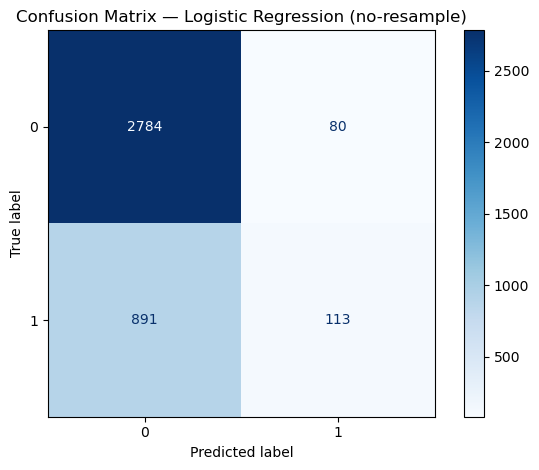


=== MLP (no-resample) ===
              precision    recall  f1-score   support

           0      0.771     0.933     0.845      2864
           1      0.526     0.211     0.301      1004

    accuracy                          0.746      3868
   macro avg      0.649     0.572     0.573      3868
weighted avg      0.708     0.746     0.704      3868

ROC-AUC: 0.7305 | F1: 0.3014 | null-accuracy baseline: 0.7404


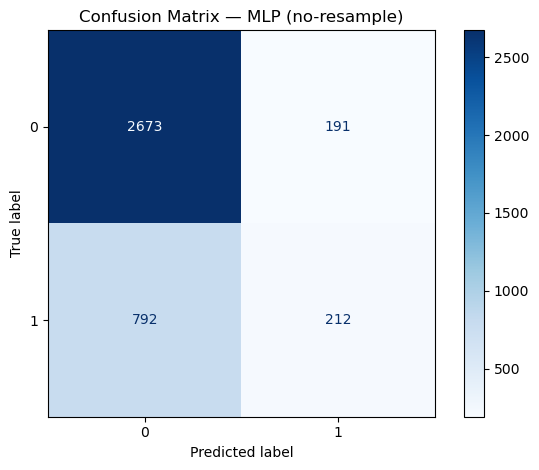


=== Logistic Regression (50/50) ===
              precision    recall  f1-score   support

           0      0.873     0.608     0.717      2864
           1      0.401     0.747     0.522      1004

    accuracy                          0.644      3868
   macro avg      0.637     0.678     0.619      3868
weighted avg      0.750     0.644     0.666      3868

ROC-AUC: 0.7231 | F1: 0.5216 | null-accuracy baseline: 0.7404


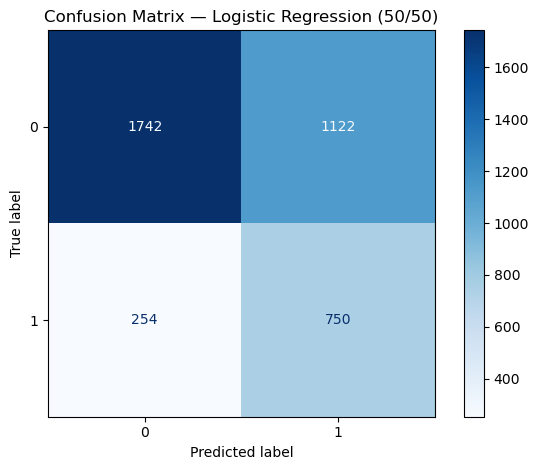


=== MLP (50/50) ===
              precision    recall  f1-score   support

           0      0.867     0.636     0.734      2864
           1      0.410     0.721     0.523      1004

    accuracy                          0.658      3868
   macro avg      0.638     0.679     0.628      3868
weighted avg      0.748     0.658     0.679      3868

ROC-AUC: 0.728 | F1: 0.5227 | null-accuracy baseline: 0.7404


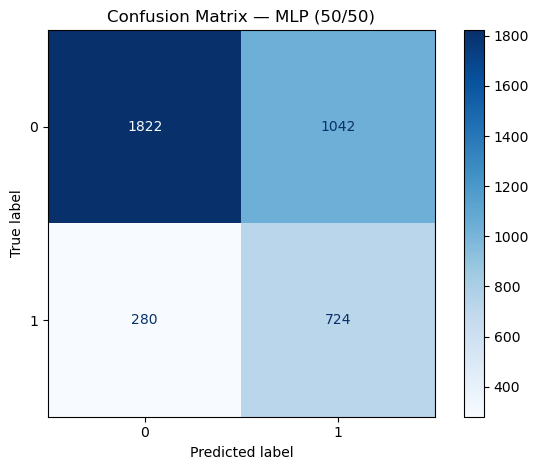

{'model': 'MLP (50/50)',
 'accuracy': 0.6582,
 'precision': 0.41,
 'recall': 0.7211,
 'f1': 0.5227,
 'roc_auc': 0.728,
 'null_acc': np.float64(0.7404),
 'n_train': 8030,
 'n_test': 3868}

In [15]:
# Logistic Regression and MLP, each no-resample then 50/50 (fresh pipeline per run).
evaluate("Logistic Regression (no-resample)", make_logreg_pipeline(),
         X_train, y_train, X_test, y_test, results_csv=RESULTS_P3, plot=True)
evaluate("MLP (no-resample)", make_mlp_pipeline(),
         X_train, y_train, X_test, y_test, results_csv=RESULTS_P3, plot=True)

evaluate("Logistic Regression (50/50)", make_logreg_pipeline(),
         X_train_bal, y_train_bal, X_test, y_test, results_csv=RESULTS_P3, plot=True)
evaluate("MLP (50/50)", make_mlp_pipeline(),
         X_train_bal, y_train_bal, X_test, y_test, results_csv=RESULTS_P3, plot=True)

# C2 — Model comparison (No-free-lunch)

We merge the per-family result files into one master table, read off the best F1 per resample policy,
and overlay the ROC curves of the 50/50 models to pick an operating model.

## Model zoo (one factory per model, using the configs found in Part 1)

In [16]:
# Each factory returns a FRESH pipeline matching the config the three teammates used
# (per-model encoding; scaling only for distance/linear/NN models; RF skips CV).
# DT/kNN values are the tuned bests found in Part 1 (50/50 variant: kNN k=49, DT min_samples_leaf=10).
def make_model(name):
    if name == "kNN":
        return Pipeline([("enc", make_encoder("onehot")),
                         ("scale", StandardScaler(with_mean=False)),
                         ("clf", KNeighborsClassifier(n_neighbors=49, n_jobs=-1))])
    if name == "Naive Bayes":
        return Pipeline([("enc", make_encoder("ordinal")),
                         ("clf", CategoricalNB(alpha=1.0))])
    if name == "Decision Tree":
        return Pipeline([("enc", make_encoder("onehot")),
                         ("clf", DecisionTreeClassifier(max_depth=None, min_samples_leaf=10,
                                                        random_state=RANDOM_STATE))])
    if name == "Random Forest":
        return Pipeline([("enc", make_encoder("onehot")),
                         ("clf", RandomForestClassifier(n_estimators=300, max_features="sqrt",
                                 max_depth=7, random_state=RANDOM_STATE, n_jobs=-1))])
    if name == "Logistic Regression":
        return Pipeline([("enc", make_encoder("onehot")),
                         ("scale", StandardScaler(with_mean=False)),
                         ("clf", LogisticRegression(C=1.0, penalty="l2", solver="lbfgs",
                                 random_state=RANDOM_STATE, max_iter=1000))])
    if name == "MLP (ANN)":
        return Pipeline([("enc", make_encoder("onehot")),
                         ("scale", StandardScaler(with_mean=False)),
                         ("clf", MLPClassifier(hidden_layer_sizes=(16,), max_iter=500,
                                 random_state=RANDOM_STATE))])
    raise ValueError(name)

ALL_MODELS = ["kNN", "Naive Bayes", "Decision Tree", "Random Forest",
              "Logistic Regression", "MLP (ANN)"]


## C2a — master comparison table

In [17]:
# ---- C2a: master comparison table from the THREE committed results files ----
# These are the authoritative, already-verified numbers (one row per model x resample).
parts = []
for f in ["results/person1_results.csv", "results/person2_results.csv", "results/person3_results.csv"]:
    parts.append(pd.read_csv(f))
master = pd.concat(parts, ignore_index=True)
master["resample"] = np.where(master["model"].str.contains("50/50"), "50/50", "no-resample")
master_sorted = master.sort_values(["f1", "roc_auc"], ascending=False).reset_index(drop=True)
print("All", len(master), "runs (sorted by F1):")
master_sorted


All 14 runs (sorted by F1):


,model,accuracy,precision,recall,f1,roc_auc,null_acc,n_train,n_test,resample
0,Random Forest (50/50),0.6450,0.4021,0.7550,0.5247,0.7278,0.7404,8030,3868,50/50
1,MLP (50/50),0.6582,0.4100,0.7211,0.5227,0.7280,0.7404,8030,3868,50/50
2,Logistic Regression (50/50),0.6443,0.4006,0.7470,0.5216,0.7231,0.7404,8030,3868,50/50
3,Decision Tree (50/50),0.6525,0.4055,0.7261,0.5203,0.7282,0.7404,8030,3868,50/50
4,CategoricalNB fit_prior=True (50/50),0.6525,0.4038,0.7112,0.5152,0.7206,0.7404,8030,3868,50/50
5,CategoricalNB fit_prior=False (50/50),0.6525,0.4038,0.7112,0.5152,0.7206,0.7404,8030,3868,50/50
6,CategoricalNB fit_prior=False (no-resample),0.6461,0.3986,0.7141,0.5116,0.7205,0.7404,15472,3868,no-resample
7,kNN (50/50),0.6365,0.3906,0.7151,0.5053,0.7105,0.7404,8030,3868,50/50
8,CategoricalNB fit_prior=True (no-resample),0.7446,0.5163,0.2520,0.3387,0.7205,0.7404,15472,3868,no-resample
9,kNN (no-resample),0.7389,0.4936,0.2301,0.3139,0.7220,0.7404,15472,3868,no-resample


## C2b — best F1 per model and resample policy

In [18]:
# Best F1 per resample policy — the headline comparison
view = master.copy()
view["base_model"] = (view["model"].str.replace(r"\s*\(.*\)", "", regex=True)
                                   .str.replace(" fit_prior=(True|False)", "", regex=True))
best = (view.sort_values("f1", ascending=False)
            .groupby(["base_model", "resample"], as_index=False).first())
pivot = best.pivot(index="base_model", columns="resample", values="f1")
print("Best F1 by model and resample policy:")
display(pivot)
print("\nNull-accuracy baseline (test):", master["null_acc"].iloc[0])


Best F1 by model and resample policy:


resample,50/50,no-resample
base_model,,
CategoricalNB,0.5152,0.5116
Decision Tree,0.5203,0.3011
Logistic Regression,0.5216,0.1888
MLP,0.5227,0.3014
Random Forest,0.5247,0.1494
kNN,0.5053,0.3139



Null-accuracy baseline (test): 0.7404


## C2c — combined ROC (50/50 models, scope2)

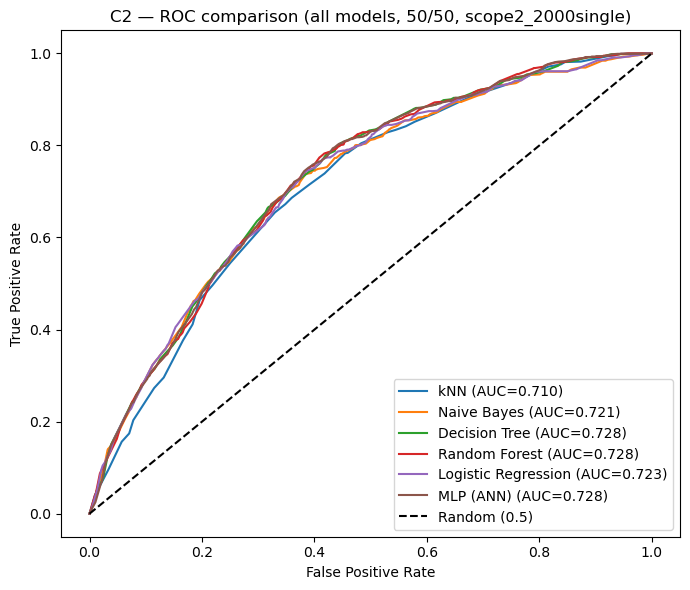

In [19]:
# ---- C2b: combined ROC for the 50/50 models on scope2 (the winning policy) ----
Xtr, Xte, ytr, yte = load_scope("data/processed/scope2_2000single")
Xtr_b, ytr_b = downsample_5050(Xtr, ytr)

fitted = {}
for name in ALL_MODELS:
    m = make_model(name)
    m.fit(Xtr_b, ytr_b)
    fitted[name] = m
plot_roc_curves(fitted, Xte, yte,
                title="C2 — ROC comparison (all models, 50/50, scope2_2000single)")


**C2 read:** all models cluster at ROC-AUC ~0.72-0.73 and 50/50 F1 ~0.50-0.53 → by No-free-lunch the model choice barely matters; the ceiling is the 3-feature signal. 50/50 downsampling is the better operating policy (lifts recall/F1; ROC-AUC ~unchanged since it is threshold-independent). **Winner = Random Forest (50/50)**: top/near-top F1, robust, taught, and gives feature importances for C3. (Decision Tree is the explainability runner-up.)

## C3 — Feature ablation (winner = Random Forest, scope2, 50/50)

In [20]:
# ---- C3: Feature ablation on the WINNING model (Random Forest, scope2, 50/50) ----
# "Does the custom Publisher_Tier machinery actually matter?" (the supervisor's 'does the tier machinery actually matter?' question).
# Framed as model comparison (No-free-lunch / ROC comparison, Lec 2 & 5): same model, different feature subsets, compare F1/ROC-AUC.
ABL_CSV = "results/phase_c_ablation.csv"
if os.path.exists(ABL_CSV): os.remove(ABL_CSV)

def rf_with(cols):
    return Pipeline([("enc", make_encoder("onehot", cat_cols=cols)),
                     ("clf", RandomForestClassifier(n_estimators=300, max_features="sqrt",
                             max_depth=7, random_state=RANDOM_STATE, n_jobs=-1))])

subsets = {
    "ALL (Genre+Platform+Tier)": CAT_COLS,
    "drop Publisher_Tier":       ["Genre_Clean", "Platform_Family"],
    "drop Genre":                ["Platform_Family", "Publisher_Tier"],
    "drop Platform":             ["Genre_Clean", "Publisher_Tier"],
    "ONLY Publisher_Tier":       ["Publisher_Tier"],
    "ONLY Genre":                ["Genre_Clean"],
    "ONLY Platform":             ["Platform_Family"],
}
abl_rows = []
for label, cols in subsets.items():
    r = evaluate(f"RF [{label}]", rf_with(cols), Xtr_b, ytr_b, Xte, yte,
                 results_csv=ABL_CSV, plot=False)
    abl_rows.append(r)
abl = pd.DataFrame(abl_rows)[["model", "f1", "roc_auc", "precision", "recall", "accuracy"]]
abl



=== RF [ALL (Genre+Platform+Tier)] ===
              precision    recall  f1-score   support

           0      0.876     0.606     0.717      2864
           1      0.402     0.755     0.525      1004

    accuracy                          0.645      3868
   macro avg      0.639     0.681     0.621      3868
weighted avg      0.753     0.645     0.667      3868

ROC-AUC: 0.7278 | F1: 0.5247 | null-accuracy baseline: 0.7404



=== RF [drop Publisher_Tier] ===
              precision    recall  f1-score   support

           0      0.800     0.603     0.688      2864
           1      0.335     0.571     0.422      1004

    accuracy                          0.595      3868
   macro avg      0.568     0.587     0.555      3868
weighted avg      0.680     0.595     0.619      3868

ROC-AUC: 0.6308 | F1: 0.4223 | null-accuracy baseline: 0.7404



=== RF [drop Genre] ===
              precision    recall  f1-score   support

           0      0.874     0.589     0.704      2864
           1      0.393     0.757     0.517      1004

    accuracy                          0.633      3868
   macro avg      0.633     0.673     0.610      3868
weighted avg      0.749     0.633     0.655      3868

ROC-AUC: 0.7058 | F1: 0.517 | null-accuracy baseline: 0.7404



=== RF [drop Platform] ===
              precision    recall  f1-score   support

           0      0.862     0.608     0.713      2864
           1      0.393     0.722     0.509      1004

    accuracy                          0.638      3868
   macro avg      0.627     0.665     0.611      3868
weighted avg      0.740     0.638     0.660      3868

ROC-AUC: 0.7174 | F1: 0.5086 | null-accuracy baseline: 0.7404



=== RF [ONLY Publisher_Tier] ===
              precision    recall  f1-score   support

           0      0.846     0.648     0.734      2864
           1      0.398     0.664     0.498      1004

    accuracy                          0.652      3868
   macro avg      0.622     0.656     0.616      3868
weighted avg      0.730     0.652     0.673      3868

ROC-AUC: 0.6852 | F1: 0.4979 | null-accuracy baseline: 0.7404



=== RF [ONLY Genre] ===
              precision    recall  f1-score   support

           0      0.808     0.510     0.625      2864
           1      0.318     0.653     0.428      1004

    accuracy                          0.547      3868
   macro avg      0.563     0.582     0.527      3868
weighted avg      0.681     0.547     0.574      3868

ROC-AUC: 0.6119 | F1: 0.4282 | null-accuracy baseline: 0.7404



=== RF [ONLY Platform] ===
              precision    recall  f1-score   support

           0      0.784     0.496     0.608      2864
           1      0.298     0.610     0.400      1004

    accuracy                          0.526      3868
   macro avg      0.541     0.553     0.504      3868
weighted avg      0.658     0.526     0.554      3868

ROC-AUC: 0.5673 | F1: 0.4001 | null-accuracy baseline: 0.7404


,model,f1,roc_auc,precision,recall,accuracy
0,RF [ALL (Genre+Platform+Tier)],0.5247,0.7278,0.4021,0.7550,0.6450
1,RF [drop Publisher_Tier],0.4223,0.6308,0.3351,0.5707,0.5946
2,RF [drop Genre],0.5170,0.7058,0.3926,0.7570,0.6329
3,RF [drop Platform],0.5086,0.7174,0.3925,0.7221,0.6378
4,RF [ONLY Publisher_Tier],0.4979,0.6852,0.3982,0.6643,0.6523
5,RF [ONLY Genre],0.4282,0.6119,0.3184,0.6534,0.5471
6,RF [ONLY Platform],0.4001,0.5673,0.2978,0.6096,0.5256


In [21]:
# How much does each feature add? (drop-one F1 vs the full set)
full_f1 = abl.loc[abl["model"].str.contains("ALL"), "f1"].iloc[0]
full_auc = abl.loc[abl["model"].str.contains("ALL"), "roc_auc"].iloc[0]
for lab in ["drop Publisher_Tier", "drop Genre", "drop Platform"]:
    row = abl[abl["model"].str.contains(lab, regex=False)].iloc[0]
    print(f"{lab:22s}: F1 {row['f1']:.3f} (Δ {row['f1']-full_f1:+.3f}) | "
          f"ROC-AUC {row['roc_auc']:.3f} (Δ {row['roc_auc']-full_auc:+.3f})")
print(f"\nFull set: F1 {full_f1:.3f} | ROC-AUC {full_auc:.3f}")
print("Bigger negative Δ when a feature is removed = that feature carries more signal.")


drop Publisher_Tier   : F1 0.422 (Δ -0.102) | ROC-AUC 0.631 (Δ -0.097)
drop Genre            : F1 0.517 (Δ -0.008) | ROC-AUC 0.706 (Δ -0.022)
drop Platform         : F1 0.509 (Δ -0.016) | ROC-AUC 0.717 (Δ -0.010)

Full set: F1 0.525 | ROC-AUC 0.728
Bigger negative Δ when a feature is removed = that feature carries more signal.


**C3 read:** removing **Publisher_Tier** should hurt the most (it had the strongest information gain in A1c and a monotonic hit-rate in A3) — quantifying it here answers the professor's 'does the tier machinery matter?' in his own model-comparison terms.

## C4 — Scope comparison (winner config across all scopes)

In [22]:
# ---- C4: Scope comparison — winning config (RF, 50/50, all features) across scopes ----
# Answers: does dropping pre-2000 help? (scope1 vs scope2)  does segmenting help? (scope2 vs eras)
SCOPE_CSV = "results/phase_c_scope.csv"
if os.path.exists(SCOPE_CSV): os.remove(SCOPE_CSV)

scopes = {
    "scope1_nocutoff":     "data/processed/scope1_nocutoff",
    "scope2_2000single":   "data/processed/scope2_2000single",
    "era1_2000-2006":      "data/processed/scope3_eras/era1_2000-2006",
    "era2_2007-2011":      "data/processed/scope3_eras/era2_2007-2011",
    "era3_2012-2018":      "data/processed/scope3_eras/era3_2012-2018",
}
scope_rows = []
for sname, spath in scopes.items():
    Xa, Xb, ya, yb = load_scope(spath)
    Xa_b, ya_b = downsample_5050(Xa, ya)
    m = make_model("Random Forest")
    r = evaluate(f"RF @ {sname}", m, Xa_b, ya_b, Xb, yb,
                 results_csv=SCOPE_CSV, plot=False)
    # train-vs-test gap (overfitting check): F1 on the (balanced) train it learned from
    from sklearn.metrics import f1_score
    tr_f1 = f1_score(ya_b, m.predict(Xa_b))
    r["train_f1"] = round(tr_f1, 4); r["gap(train-test)"] = round(tr_f1 - r["f1"], 4)
    scope_rows.append(r)
scope_df = pd.DataFrame(scope_rows)[["model","f1","roc_auc","recall","precision",
                                     "train_f1","gap(train-test)","n_train","n_test"]]
scope_df



=== RF @ scope1_nocutoff ===
              precision    recall  f1-score   support

           0      0.868     0.576     0.692      3131
           1      0.388     0.755     0.513      1117

    accuracy                          0.623      4248
   macro avg      0.628     0.665     0.603      4248
weighted avg      0.742     0.623     0.645      4248

ROC-AUC: 0.7209 | F1: 0.5128 | null-accuracy baseline: 0.7371



=== RF @ scope2_2000single ===
              precision    recall  f1-score   support

           0      0.876     0.606     0.717      2864
           1      0.402     0.755     0.525      1004

    accuracy                          0.645      3868
   macro avg      0.639     0.681     0.621      3868
weighted avg      0.753     0.645     0.667      3868

ROC-AUC: 0.7278 | F1: 0.5247 | null-accuracy baseline: 0.7404



=== RF @ era1_2000-2006 ===
              precision    recall  f1-score   support

           0      0.816     0.610     0.698       894
           1      0.367     0.622     0.461       325

    accuracy                          0.613      1219
   macro avg      0.591     0.616     0.580      1219
weighted avg      0.696     0.613     0.635      1219

ROC-AUC: 0.6755 | F1: 0.4612 | null-accuracy baseline: 0.7334



=== RF @ era2_2007-2011 ===
              precision    recall  f1-score   support

           0      0.907     0.562     0.694      1285
           1      0.387     0.828     0.527       429

    accuracy                          0.628      1714
   macro avg      0.647     0.695     0.610      1714
weighted avg      0.777     0.628     0.652      1714

ROC-AUC: 0.7589 | F1: 0.5271 | null-accuracy baseline: 0.7497



=== RF @ era3_2012-2018 ===
              precision    recall  f1-score   support

           0      0.873     0.730     0.795       686
           1      0.489     0.708     0.578       250

    accuracy                          0.724       936
   macro avg      0.681     0.719     0.687       936
weighted avg      0.770     0.724     0.737       936

ROC-AUC: 0.7747 | F1: 0.5784 | null-accuracy baseline: 0.7329


,model,f1,roc_auc,recall,precision,train_f1,gap(train-test),n_train,n_test
0,RF @ scope1_nocutoff,0.5128,0.7209,0.7547,0.3883,0.7072,0.1944,8936,4248
1,RF @ scope2_2000single,0.5247,0.7278,0.7550,0.4021,0.7168,0.1921,8030,3868
2,RF @ era1_2000-2006,0.4612,0.6755,0.6215,0.3666,0.6732,0.2120,2604,1219
3,RF @ era2_2007-2011,0.5271,0.7589,0.8275,0.3867,0.7163,0.1892,3430,1714
4,RF @ era3_2012-2018,0.5784,0.7747,0.7080,0.4890,0.7168,0.1384,1996,936


**C4 read (caution — these are per-scope test sets):** each row is scored on its *own* test set, so the table mixes model quality with test-set difficulty. Read it as a *descriptive* profile, not proof that one scope is "better": era-3 (2012–18) looks best and era-1 (2000–06) weakest because recent releases are easier to call, not because segmenting helps. Watch `gap(train-test)`: the small 2012–18 era has the largest overfitting risk. The fair, confound-free comparison (fixed test rows) is in the **C4-fair** cell below — it shows the cutoff is non-critical and a single pooled model is best.

## C4-fair — same test rows + grouped split (removes the population confound)

The C4 table above scores each scope/era on its **own** test set, so it mixes *model quality* with *test-set difficulty* — that comparison cannot, on its own, say whether segmenting or dropping pre-2000 actually helps. These checks hold the **test rows fixed** and vary only the training data (plus a title-grouped re-split), giving confound-free answers:

- **(1.2) Drop pre-2000?** On the *same* 2000+ test rows, training with vs without pre-2000 is a tie (AUC ~0.731 vs ~0.727) → the scope cutoff is **non-critical**, not a real gain.
- **(1.1) Segment into eras?** On *identical* era-3 test rows the **pooled** 2000–2018 model beats the era-only model (AUC ~0.81 vs ~0.74); era-1 is a tie. So era-segmenting does **not** help — one pooled model is best (more training data, richer tier lookup). The era differences in the C4 table reflect the *test population*, not the model: **recent releases are intrinsically more predictable.**
- **(2.1) Duplicate-title leakage?** Multi-platform releases put the same title on both sides of a random split. A grouped split (no title shared) gives ~0.513/0.730 vs 0.525/0.728 → unchanged, so duplicate titles do not inflate the metrics.

In [23]:
# ---- C4-FAIR: same-test-rows comparisons (fixes the population confound in C4) ----
# C4 above scores each scope/era on its OWN test set (different populations), which conflates
# "model quality" with "test-set difficulty". Here we hold the TEST ROWS FIXED and vary only the
# TRAIN set (plus a grouped re-split), so the comparison is fair. Year is needed and is not in the
# processed CSVs, so we rebuild the phase_b logic in memory: raw -> usable -> Hit -> features.
# Writes NOTHING to disk. Model = the winner config (RF, 50/50, all features).
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import f1_score, roc_auc_score

raw = pd.read_csv('data/Video Games Sales (1980-2024) - Raw.csv')
raw['year'] = pd.to_datetime(raw['release_date'], errors='coerce', dayfirst=True).dt.year
u = raw[(raw['total_sales'].notna() | raw['critic_score'].notna()) & raw['year'].notna()].copy()
thr = u[u['total_sales'].notna()].groupby('year')['total_sales'].quantile(0.75)
u['Hit'] = ((u['total_sales'].notna() & (u['total_sales'] >= u['year'].map(thr)))
            | (u['critic_score'] >= 8.5)).astype(int)
small = ['Board Game', 'Sandbox', 'Education', 'Party', 'MMO', 'Music', 'Visual Novel']
u['Genre_Clean'] = u['genre'].where(~u['genre'].isin(small), 'Other')
fam = {**{k: 'Playstation' for k in ['PS','PS2','PS3','PS4','PS5','PSP','PSV','PSN','BRW']},
       **{k: 'Xbox' for k in ['XB','X360','XOne','XS','XBL']},
       **{k: 'Nintendo' for k in ['DS','GBA','Wii','NS','3DS','WiiU','GC','N64','GB','DSi','DSiW','VC','GBC','WW','WS']},
       **{k: 'PC' for k in ['PC','OSX','Linux','WinP']}, **{k: 'Mobile' for k in ['And','iOS','Mob']}}
u['Platform_Family'] = u['console'].map(fam).fillna('Other')

def add_tier(tr, te):   # identical to phase_b: train-only tier, test lookup, unseen -> Tier1
    ps = tr.groupby(['title', 'publisher']).agg(s=('total_sales', 'sum'),
                                                c=('critic_score', 'max')).reset_index()
    cnt = ps[(ps['s'] > 10) | (ps['c'] >= 9)].groupby('publisher').size()
    mp = cnt.apply(lambda c: 'Tier3' if c >= 5 else 'Tier2').to_dict()
    tr, te = tr.copy(), te.copy()
    tr['Publisher_Tier'] = tr['publisher'].map(mp).fillna('Tier1')
    te['Publisher_Tier'] = te['publisher'].map(mp).fillna('Tier1')
    return tr, te

def rf_run(tr, te, label):
    tr, te = add_tier(tr, te)
    Xb, yb = downsample_5050(tr[CAT_COLS], tr['Hit'])
    m = make_model("Random Forest"); m.fit(Xb, yb)
    f1 = f1_score(te['Hit'], m.predict(te[CAT_COLS]))
    auc = roc_auc_score(te['Hit'], m.predict_proba(te[CAT_COLS])[:, 1])
    print(f"{label:54s} F1={f1:.4f}  AUC={auc:.4f}  n_test={len(te)}")
    return f1, auc

cap = u[u['year'] <= 2018]; d2 = cap[cap['year'] >= 2000]
tr, te = train_test_split(d2, test_size=0.2, random_state=RANDOM_STATE, stratify=d2['Hit'])
print("sanity (should match committed RF scope2 = F1 .5247 / AUC .7278):")
rf_run(tr, te, "  scope2 random split")

print("\n(1.2) pre-2000 effect on the SAME 2000+ test rows (train varies, test fixed):")
tr1, te1 = train_test_split(cap, test_size=0.2, random_state=RANDOM_STATE, stratify=cap['Hit'])
te_mod = te1[te1['year'] >= 2000]
rf_run(tr1, te_mod,                        "  train WITH pre-2000   -> 2000+ test")
rf_run(tr1[tr1['year'] >= 2000], te_mod,   "  train WITHOUT pre-2000 -> same test")

print("\n(1.1) pooled vs era-only model on IDENTICAL era test rows:")
for lo, hi, nm in [(2000, 2006, 'era1'), (2012, 2018, 'era3')]:
    te_e = te[(te['year'] >= lo) & (te['year'] <= hi)]
    rf_run(tr, te_e,                                          f"  POOLED 2000-18 -> {nm} test rows")
    rf_run(tr[(tr['year'] >= lo) & (tr['year'] <= hi)], te_e, f"  {nm}-only       -> same rows")

print("\n(2.1) grouped split by title (no game on both sides) — duplicate-title leakage check:")
i_tr, i_te = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
                  .split(d2, groups=d2['title']))
rf_run(d2.iloc[i_tr], d2.iloc[i_te], "  grouped-by-title split (vs random .525/.728)")

sanity (should match committed RF scope2 = F1 .5247 / AUC .7278):


  scope2 random split                                  F1=0.5247  AUC=0.7278  n_test=3868

(1.2) pre-2000 effect on the SAME 2000+ test rows (train varies, test fixed):


  train WITH pre-2000   -> 2000+ test                  F1=0.5187  AUC=0.7307  n_test=3854


  train WITHOUT pre-2000 -> same test                  F1=0.5181  AUC=0.7268  n_test=3854

(1.1) pooled vs era-only model on IDENTICAL era test rows:


  POOLED 2000-18 -> era1 test rows                     F1=0.4634  AUC=0.6634  n_test=1237


  era1-only       -> same rows                         F1=0.4622  AUC=0.6748  n_test=1237


  POOLED 2000-18 -> era3 test rows                     F1=0.5988  AUC=0.8099  n_test=976


  era3-only       -> same rows                         F1=0.5076  AUC=0.7414  n_test=976

(2.1) grouped split by title (no game on both sides) — duplicate-title leakage check:


  grouped-by-title split (vs random .525/.728)         F1=0.5132  AUC=0.7302  n_test=3911


(0.5131752305665349, 0.7302033268813324)

## C5 — Downsampling ablation (summary)

In [24]:
# ---- C5 (downsampling) is already embedded above: every model has no-resample vs 50/50 in C2. ----
# Quick C5 summary: average F1 lift from no-resample -> 50/50 across all base models.
lift = (best.pivot(index="base_model", columns="resample", values="f1"))
lift["lift(50/50 - none)"] = lift["50/50"] - lift["no-resample"]
print("C5 — downsampling effect on F1:")
display(lift)
print("Average F1 lift from 50/50 downsampling:", round(lift["lift(50/50 - none)"].mean(), 3))


C5 — downsampling effect on F1:


resample,50/50,no-resample,lift(50/50 - none)
base_model,,,
CategoricalNB,0.5152,0.5116,0.0036
Decision Tree,0.5203,0.3011,0.2192
Logistic Regression,0.5216,0.1888,0.3328
MLP,0.5227,0.3014,0.2213
Random Forest,0.5247,0.1494,0.3753
kNN,0.5053,0.3139,0.1914


Average F1 lift from 50/50 downsampling: 0.224


## C3/C4 Robustness — repeat across the TOP-3 models

The winner-only analyses above are confirmed here against the next-best models, so the conclusions are shown to be **model-independent** (defends against an 'RF artifact?' objection; consistent with C2's clustering and the model-free information-gain evidence in A1c).

In [25]:
# ---- Robustness: rerun C3 & C4 across the TOP-3 models (not just the winner) ----
# Goal: show the ablation & scope FINDINGS are not a Random-Forest artifact.
from sklearn.metrics import f1_score, roc_auc_score

TOP3 = ["Random Forest", "MLP (ANN)", "Logistic Regression"]  # 3 different model families

def build(name, cols):
    """Same configs as make_model(), but with a chosen feature subset (cols)."""
    enc = make_encoder("onehot", cat_cols=cols)
    if name == "Random Forest":
        return Pipeline([("enc", enc),
                         ("clf", RandomForestClassifier(n_estimators=300, max_features="sqrt",
                                 max_depth=7, random_state=RANDOM_STATE, n_jobs=-1))])
    if name == "MLP (ANN)":
        return Pipeline([("enc", enc), ("scale", StandardScaler(with_mean=False)),
                         ("clf", MLPClassifier(hidden_layer_sizes=(16,), max_iter=500,
                                 random_state=RANDOM_STATE))])
    if name == "Logistic Regression":
        return Pipeline([("enc", enc), ("scale", StandardScaler(with_mean=False)),
                         ("clf", LogisticRegression(C=1.0, penalty="l2", solver="lbfgs",
                                 random_state=RANDOM_STATE, max_iter=1000))])
    raise ValueError(name)

def fit_metrics(pipe, Xa, ya, Xb, yb):
    pipe.fit(Xa, ya)
    return f1_score(yb, pipe.predict(Xb)), roc_auc_score(yb, pipe.predict_proba(Xb)[:, 1])


### C3-robust — does *every* top model rank Publisher_Tier as the biggest loss?

In [26]:
# C3-robust: feature ablation across TOP-3 (scope2, 50/50). Reuses subsets, Xtr_b/ytr_b/Xte/yte.
rows = []
for label, cols in subsets.items():
    for name in TOP3:
        f1, auc = fit_metrics(build(name, cols), Xtr_b, ytr_b, Xte, yte)
        rows.append({"subset": label, "model": name, "f1": f1, "roc_auc": auc})
abl3 = pd.DataFrame(rows)
order = list(subsets.keys())
f1_tab = abl3.pivot(index="subset", columns="model", values="f1").reindex(order)[TOP3]
print("C3-robust — F1 by feature subset x model (scope2, 50/50):")
display(f1_tab.round(3))
print("\nF1 drop when a feature is removed (vs ALL), per model:")
full = f1_tab.loc["ALL (Genre+Platform+Tier)"]
display((f1_tab.loc[["drop Publisher_Tier","drop Genre","drop Platform"]] - full).round(3))


C3-robust — F1 by feature subset x model (scope2, 50/50):


model,Random Forest,MLP (ANN),Logistic Regression
subset,,,
ALL (Genre+Platform+Tier),0.5250,0.5230,0.5220
drop Publisher_Tier,0.4220,0.4350,0.4380
drop Genre,0.5170,0.5170,0.5170
drop Platform,0.5090,0.5090,0.5060
ONLY Publisher_Tier,0.4980,0.4980,0.4980
ONLY Genre,0.4280,0.4280,0.4280
ONLY Platform,0.4000,0.4000,0.4000



F1 drop when a feature is removed (vs ALL), per model:


model,Random Forest,MLP (ANN),Logistic Regression
subset,,,
drop Publisher_Tier,-0.1020,-0.0880,-0.0830
drop Genre,-0.0080,-0.0060,-0.0050
drop Platform,-0.0160,-0.0140,-0.0150


### C4-robust — does the scope *profile* (recent eras score highest, pre-2000 lowest) hold for every top model?

(Same caveat as C4: each scope is on its own test set. This checks the ordering is not an RF artifact; the *fair* same-test-rows comparison is in the C4-fair cell.)

In [27]:
# C4-robust: scope comparison across TOP-3 (RF/MLP/LogReg, full features, 50/50).
rows = []
for sname, spath in scopes.items():
    Xa, Xb, ya, yb = load_scope(spath)
    Xa_b, ya_b = downsample_5050(Xa, ya)
    for name in TOP3:
        f1, auc = fit_metrics(build(name, CAT_COLS), Xa_b, ya_b, Xb, yb)
        rows.append({"scope": sname, "model": name, "f1": f1, "roc_auc": auc})
sc3 = pd.DataFrame(rows)
print("C4-robust — ROC-AUC by scope x model:")
display(sc3.pivot(index="scope", columns="model", values="roc_auc").reindex(list(scopes.keys()))[TOP3].round(3))
print("\nC4-robust — F1 by scope x model:")
display(sc3.pivot(index="scope", columns="model", values="f1").reindex(list(scopes.keys()))[TOP3].round(3))


C4-robust — ROC-AUC by scope x model:


model,Random Forest,MLP (ANN),Logistic Regression
scope,,,
scope1_nocutoff,0.7210,0.7240,0.7040
scope2_2000single,0.7280,0.7280,0.7230
era1_2000-2006,0.6750,0.6810,0.6760
era2_2007-2011,0.7590,0.7520,0.7420
era3_2012-2018,0.7750,0.7650,0.7720



C4-robust — F1 by scope x model:


model,Random Forest,MLP (ANN),Logistic Regression
scope,,,
scope1_nocutoff,0.5130,0.5190,0.5090
scope2_2000single,0.5250,0.5230,0.5220
era1_2000-2006,0.4610,0.4810,0.4630
era2_2007-2011,0.5270,0.5350,0.5200
era3_2012-2018,0.5780,0.5610,0.5720


## Phase C conclusions (for the report)

1. **Model:** No-free-lunch holds — models are statistically close (ROC-AUC ~0.73). Pick **Random Forest** for the F1 edge + robustness; **Decision Tree** for explainability.
2. **Imbalance:** report F1/ROC-AUC, not accuracy; **50/50 downsampling** is the operating policy (recall/F1 up, ROC-AUC unchanged) — both of the professor's imbalance fixes shown (imbalance-aware metrics + 50/50 class balancing, Lec 5).
3. **Features:** ablation quantifies each feature's contribution — **Publisher_Tier dominates** (drop-Tier costs ~0.10 F1/AUC; Tier alone ≈ full set), confirmed across the top-3 models — the 'does our engineering matter?' answer (the supervisor's feature-value question).
4. **Scope (fair comparison):** holding the test rows fixed, dropping pre-2000 is a tie → the cutoff is **non-critical**, and era-segmenting does **not** beat a single pooled 2000–2018 model (pooled AUC ~0.81 vs ~0.74 on identical era-3 rows). The era differences are a property of the *data* — **recent releases are intrinsically more predictable** — not a reason to segment. One pooled model is the recommended policy.
5. **Robustness:** a title-grouped split (no game on both sides) leaves the winner unchanged (~0.513/0.730 vs 0.525/0.728), so multi-platform duplicate titles do not inflate the metrics.
6. **Honest ceiling:** ~0.73 AUC reflects missing hype drivers (marketing, pre-orders, wishlists) — a stated limitation, not a modeling failure.